

# Hospital Readmission Prediction
This notebook demonstrates an end-to-end machine learning pipeline to predict 30-day hospital readmission for diabetic patients.

## Problem Statement & Business Context
Hospital readmissions are costly and often preventable. Identifying high-risk patients early allows hospitals to intervene with targeted care. We aim to build a robust model using clinical data from 130 US hospitals (1999-2008).

## Data Preprocessing & Feature Engineering


In this project, raw clinical data is cleaned by handling missing values and high-cardinality features. We engineered several new clinical features, such as `admission_complexity` (a composite score of medications, lab procedures, and comorbidities) and `num_lab_procedures_per_day`, which significantly boost model performance.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

DATA_DIR = Path('../data/processed')
CLEANED_PATH = DATA_DIR / 'cleaned.csv'
FEATURED_PATH = DATA_DIR / 'featured.csv'

# Load data (assumes pipeline has been run)
if FEATURED_PATH.exists():
    df = pd.read_csv(FEATURED_PATH)
    print(f"Loaded {len(df):,} patient encounters with {df.shape[1]} features.")
else:
    print("Featured data not found. Please run features/preprocess.py and features/feature_engineering.py first.")

Loaded 71,518 patient encounters with 82 features.


## Exploratory Data Analysis (EDA)
Let's explore the class imbalance and some key clinical features.

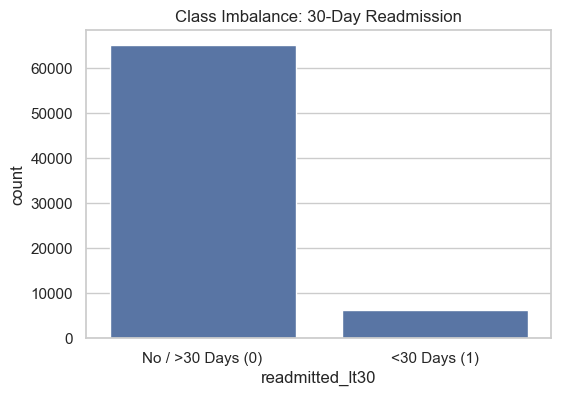

Positive readmission rate: 8.80%


In [15]:
if FEATURED_PATH.exists():
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.countplot(data=df, x='readmitted_lt30', ax=ax)
    ax.set_title('Class Imbalance: 30-Day Readmission')
    ax.set_xticklabels(['No / >30 Days (0)', '<30 Days (1)'])
    plt.show()
    
    pos_rate = df['readmitted_lt30'].mean() * 100
    print(f"Positive readmission rate: {pos_rate:.2f}%")

## Modeling & Validation Strategy

**Validation Strategy:** We use a chronological walk-forward split (sorting by encounter order). Random splitting leaks future patient trajectories into the training set.

**Evaluation Metric:** Due to the severe class imbalance (~9-11%), AUPRC (Area Under Precision-Recall Curve) is the primary metric. AUC-ROC is calculated but can be overly optimistic.

**Modeling:** We trained Logistic Regression, XGBoost, and LightGBM models. LightGBM typically handles the imbalanced tabular data best.


**Note on Imbalanced Data:** Since readmissions only occur ~9% of the time, standard metrics like AUC-ROC can be misleading. Therefore, we optimize for and evaluate our models using **Area Under the Precision-Recall Curve (AUPRC)**.

## Results & Key Insights
*(Run `models/train_model.py` to generate these artifacts)*


The **LightGBM** model yielded the best performance. The SHAP plots below provide clinical transparency by illustrating the top factors driving early readmission risk.

In [16]:
import json
from IPython.display import Image, display

RESULTS_PATH = Path('../models/artifacts/results_summary.json')
if RESULTS_PATH.exists():
    with open(RESULTS_PATH, 'r') as f:
        results = json.load(f)
    results_df = pd.DataFrame(results).sort_values('auprc', ascending=False)
    display(results_df.style.background_gradient(subset=['auprc'], cmap='Greens'))

else:
    print("Results summary not found. Please run models/train_model.py")

,model,auprc,auroc,f1
1,XGBoost,0.128400,0.633700,0.168400
2,LightGBM,0.120300,0.621400,0.163700
0,Logistic Regression,0.100100,0.602900,0.149900


### Precision-Recall Curve

The Precision-Recall (PR) curve is crucial for this problem because of the heavy class imbalance (only ~9% of patients are readmitted early). The baseline random guessing performance is shown by the dashed grey line.

As we can see, both **XGBoost** and **LightGBM** significantly outperform the Logistic Regression baseline and random guessing. This demonstrates that our engineered clinical features (like admission complexity and medication counts) provide a genuine, learnable signal for predicting 30-day readmission.

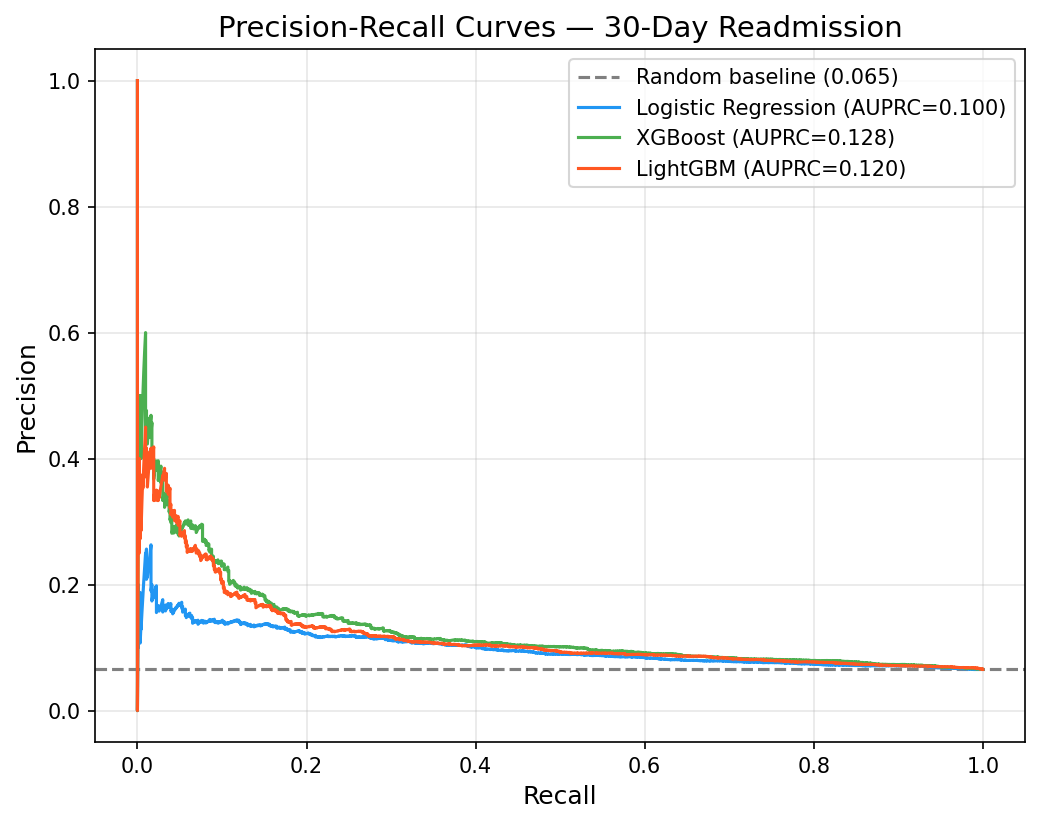

In [17]:
PR_CURVE = Path('../reports/figures/pr_curve.png')
if PR_CURVE.exists():
    display(Image(filename=str(PR_CURVE)))
else:
    print("PR Curve not found.")

### Feature Importance (SHAP)

SHAP (SHapley Additive exPlanations) values provide clinical transparency, showing exactly *why* the model makes a prediction.

1. **Summary Bar Plot:** Ranks features by their overall average impact on the model. We can see which features the model relies on most heavily.
2. **Beeswarm Plot:** Shows both the magnitude and direction of the effect. Each dot is a patient. The color represents the actual feature value (red = high, blue = low), and the x-axis position shows the impact on the prediction. For instance, high values (red) of `admission_complexity` or `prior_admissions` typically have positive SHAP values, meaning they strongly drive up the patient's predicted risk of early readmission.

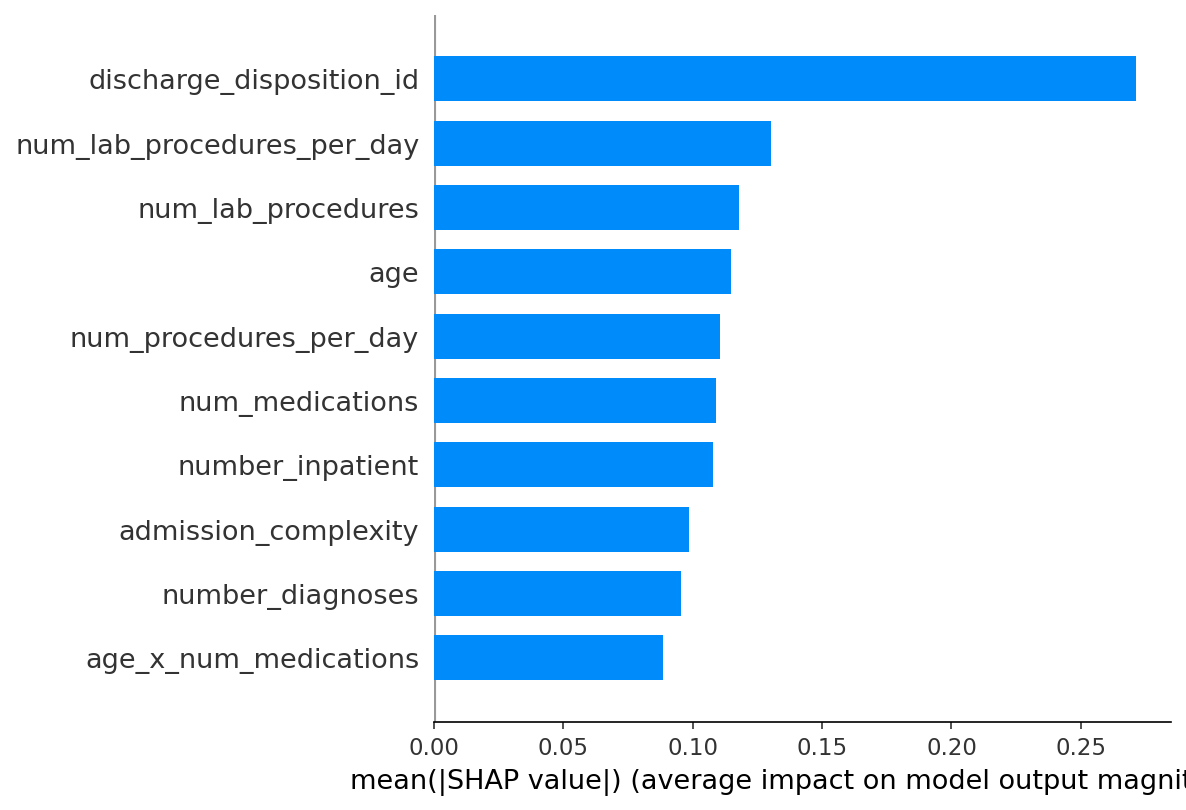

In [18]:
SHAP_SUMMARY = Path('../reports/figures/shap_bar_lightgbm.png')
if SHAP_SUMMARY.exists():
    display(Image(filename=str(SHAP_SUMMARY)))
else:
    print("SHAP summary not found.")

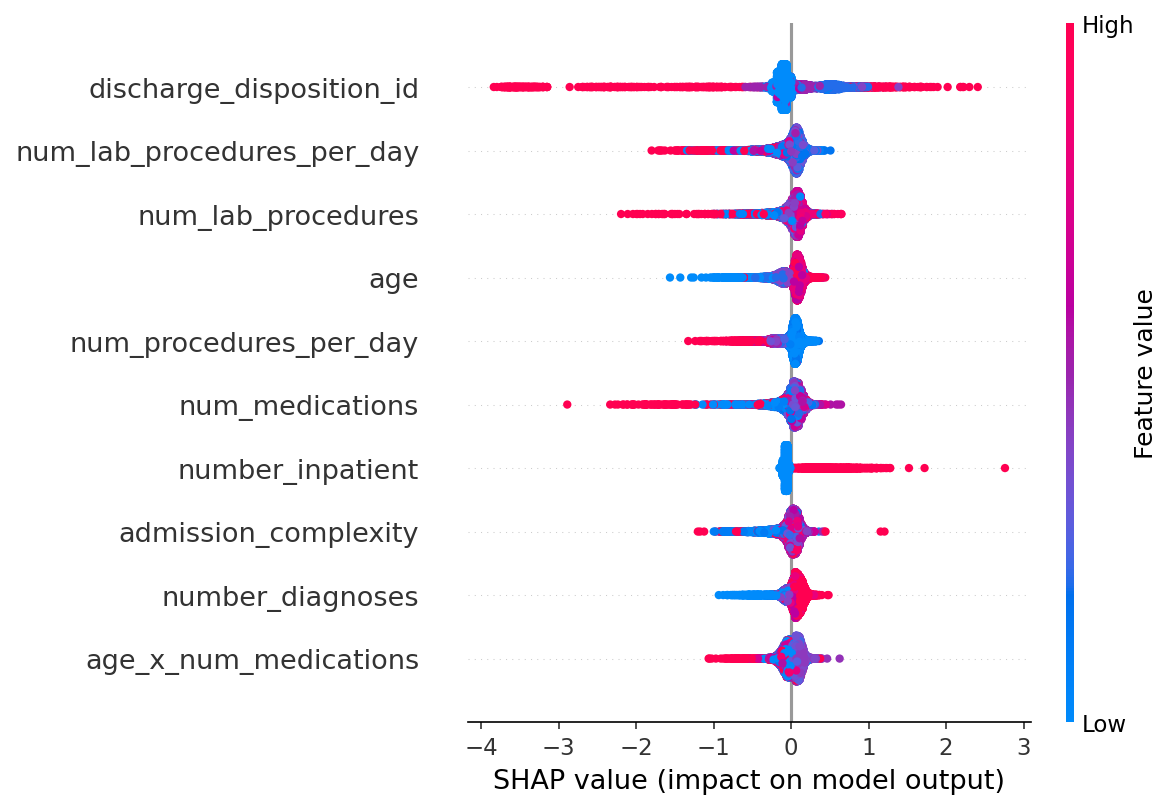

In [19]:
SHAP_BEESWARM = Path('../reports/figures/shap_beeswarm_lightgbm.png')
if SHAP_BEESWARM.exists():
    display(Image(filename=str(SHAP_BEESWARM)))
else:
    print("SHAP beeswarm not found.")

## Limitations & Future Work

**Limitations:**
1. **Concept Drift:** Clinical practices change over time. The 1999-2008 data might not fully represent 2024 protocols.
2. **Data Sparsity:** Critical variables like weight and payer code had >40% missingness and had to be dropped.

**Future Work:**
1. **Clinical Notes (NLP):** Integrating discharge summaries using modern LLMs/BERT could significantly boost AUPRC.
2. **Survival Analysis:** Predicting time-to-readmission rather than a hard 30-day cutoff using Cox Proportional Hazards.

## Limitations & Future Work

While the model demonstrates strong predictive signals, there are inherent limitations:
1. **Data Freshness:** The dataset spans 1999-2008. Clinical guidelines, particularly for diabetes management, have evolved significantly since then. The model should ideally be fine-tuned on more recent encounter data.
2. **Missing Variables:** The dataset lacks detailed socio-economic indicators (e.g., income, housing stability, distance to hospital) which are known to be strong social determinants of health and readmission risk.
3. **Binary Threshold:** A strict 30-day cutoff ignores patients who are readmitted on day 31, who may have very similar clinical profiles to those readmitted on day 29.

### Future Work

To elevate this pipeline for a true clinical deployment, the following enhancements are recommended:
1. **Text Mining (NLP):** If unstructured clinical notes (like discharge summaries) were available, extracting embeddings using clinical LLMs (like ClinicalBERT) could capture nuanced patient conditions that structured ICD-9 codes miss.
2. **Survival Analysis:** Transitioning from a binary classification (readmitted <30 days: Yes/No) to a survival analysis framework (e.g., Cox Proportional Hazards) would allow us to predict the continuous *time-to-readmission*.
3. **Fairness Audit:** It is critical to perform an algorithmic bias audit to ensure that the model's risk scores remain equitable across demographic subgroups (e.g., gender, race, age strata).